In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc
import math

# global_path = "/home/ids/edabier/HSU"
global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/edabier/miniconda3/envs/hsu-env/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.mod

Using device: cuda:0


feature shape: (1024, 16, 16)
Unmixing model has 2.322971M params


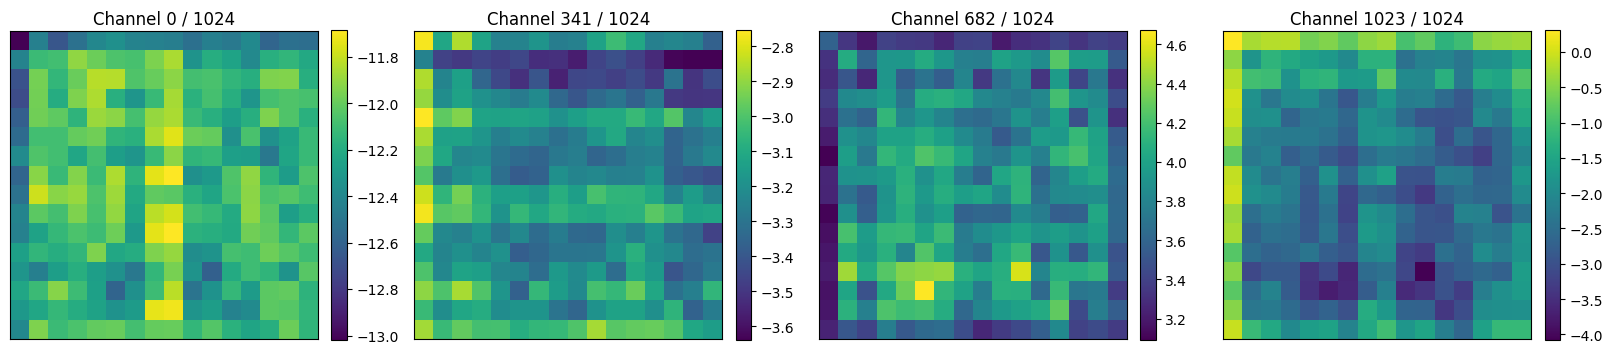

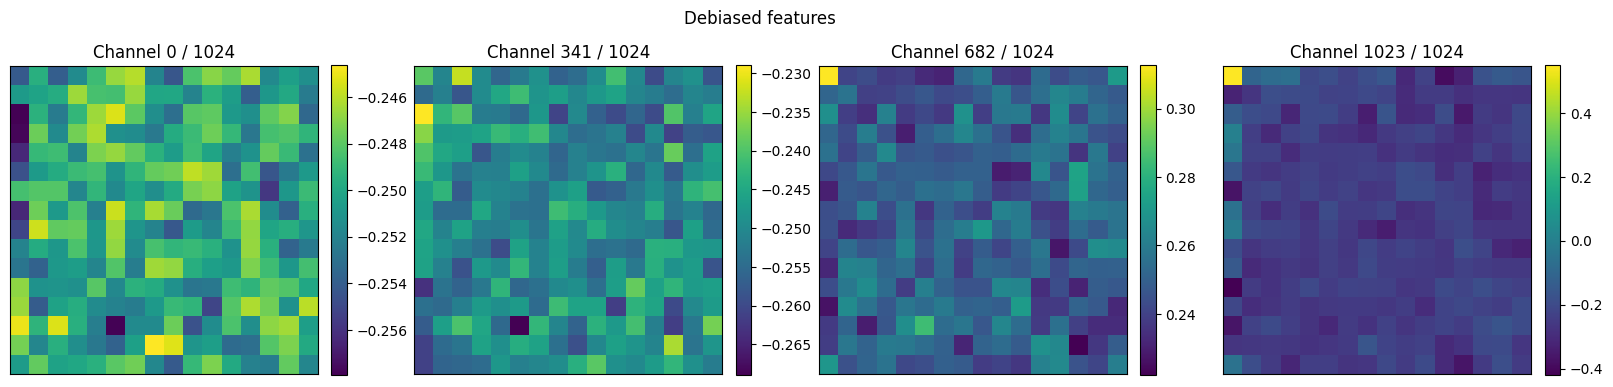

In [2]:
dataset = "samson"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
Y_init = torch.zeros_like(Y_init)
A = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm_name = "DOFA"
fm, Y_init_fm, new_H = rsfm.create_fm(fm_name, Y_init, c=c, size="large", version="v2", path=global_path)

if fm_name == "HyperSIGMA":
    _, features = rsfm.extract_f(fm, Y_init_fm[:,:,:64,:64], new_H, wavelengths)
else:
    _, features = rsfm.extract_f(fm, Y_init_fm, new_H, wavelengths)
    features = utils.oneD_to_2d(features)

# features = features[:, 1:-1, 1:-1]
D = int(features.shape[0])
alpha = int(features.shape[1])

print(f"feature shape: {D, alpha, alpha}")

_, A_init_fm = rsfm.reshape_Y(fm_name, Y_init, new_H, A) 
title = f"H = {new_H}, "
title += r"$\alpha$"
title += f" = {alpha}"

db_features = rsfm.debias_features(features, fm, B, new_H, wavelengths, svd_components=10)
# plots.plot_hsi(Y_init_fm, 4)
plots.plot_hsi(features, 4)#, title=title)
plots.plot_hsi(db_features, 4, title="Debiased features")

unmixer = rsfm.Unmixing_from_features(D=D, H=min(new_H, H), alpha=alpha, B=B, c=c)
print(f"Unmixing model has {sum(p.numel() for p in unmixer.parameters() if p.requires_grad)/1e6}M params")

100%|██████████| 16/16 [02:04<00:00,  7.75s/it]


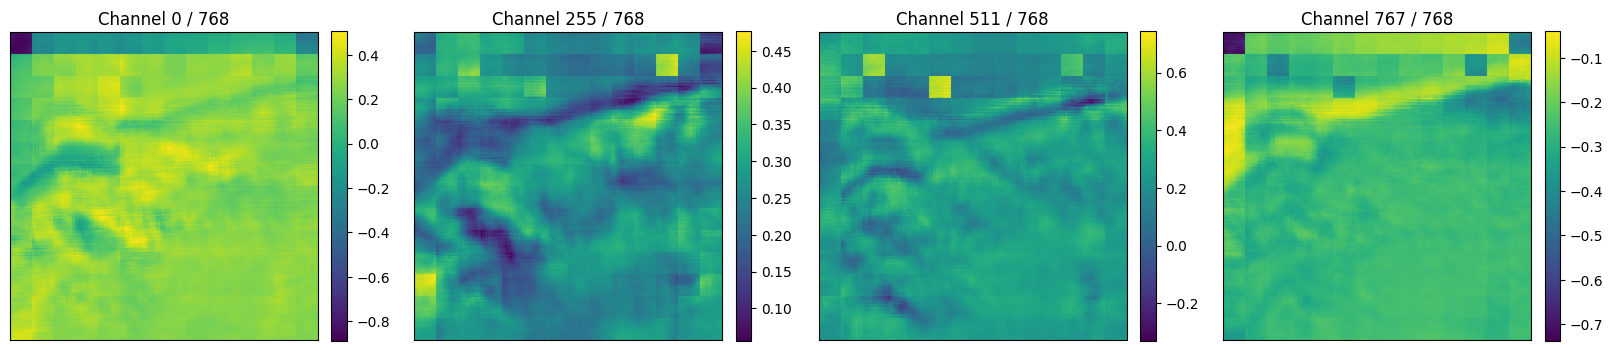

In [11]:
patch = new_H//alpha
padding = patch//2
shift = 1

x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

epochs, lr = 200, 0.002
optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

Y_padded = F.pad(Y_init_fm, pad=(padding, padding, padding, padding), mode="reflect")
feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

with torch.no_grad():
    for i in tqdm(range(0, 2*padding)):
        for j in range(0, 2*padding):

            n_crop = patch*(i//shift) + j//shift
            
            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths)

            features = utils.oneD_to_2d(features)
            features = rsfm.debias_features(features, fm, B, new_H, wavelengths, svd_components=10)
            
            # features = features[:, 1:-1, 1:-1]

            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()
plots.plot_hsi(feature_map, 4)

In [12]:
# H_final = min(H, new_H)
# patch = math.ceil(H_final/alpha)
# padding = patch//2
# shift = 1
# H_features = alpha*patch
# x_new = torch.linspace(0, H_final - 1, H_final)
# grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
# grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
# grid = grid / torch.tensor([(H_final - 1) / 2, (H_final - 1) / 2]) - 1

# Y_padded = F.pad(Y_init_fm, pad=(padding, padding, padding, padding), mode="reflect")
# feature_map = torch.zeros(1, D, H_features, H_features, device=dev)

# with torch.no_grad():
#     for i in tqdm(range(0, 2*padding)):
#         for j in range(0, 2*padding):
            
#             # Y_crop = Y_padded[:, :, i:i+H_final, j:j+H_final]
#             Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
#             Y_crop = Y_crop.to(dev)
#             _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)

#             features = features.reshape(1, D, alpha, alpha)
#             feature_map[:,:, i::patch, j::patch] = features
            
#             del features, Y_crop
#             torch.cuda.synchronize()
#             torch.cuda.empty_cache()
#             gc.collect()
            
# feature_map_resampled = F.grid_sample(feature_map, grid, mode='bilinear', padding_mode='reflection', align_corners=True)
# plots.plot_hsi(feature_map_resampled, 4)

  0%|          | 0/10 [00:00<?, ?it/s]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 10%|█         | 1/10 [00:02<00:19,  2.19s/it]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 20%|██        | 2/10 [00:04<00:17,  2.16s/it]

...

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


 90%|█████████ | 9/10 [00:19<00:02,  2.21s/it]

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


100%|██████████| 10/10 [00:21<00:00,  2.18s/it]


Average SAD = 0.059 ± 0.055, MSE = 0.069 ± 0.052


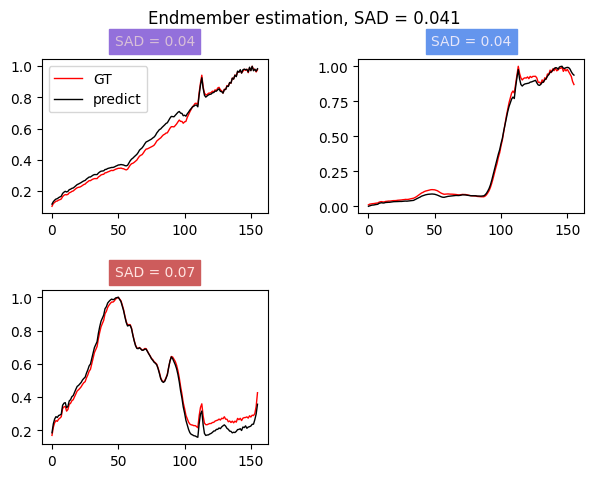

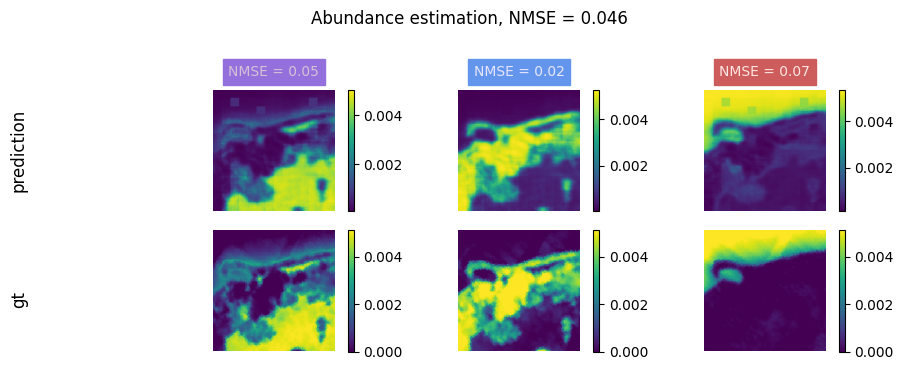

In [13]:
patch = new_H//alpha
padding = patch//2
shift = 1
x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

epochs, lr = 200, 0.002
optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

# Y_padded = F.pad(Y_init_fm, pad=(padding, padding, padding, padding), mode="reflect")
# feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

# with torch.no_grad():
#     for i in tqdm(range(0, 2*padding)):
#         for j in range(0, 2*padding):

#             n_crop = patch*(i//shift) + j//shift
            
#             Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
#             Y_crop = Y_crop.to(dev)
#             _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths)

#             features = features.reshape(1, D, alpha, alpha)
#             feature_map[:,:, i::patch, j::patch] = features
            
#             del features, Y_crop
#             torch.cuda.synchronize()
#             torch.cuda.empty_cache()
#             gc.collect()

feature_map = (feature_map - feature_map.mean())/(1e-8 + feature_map.std())
# feature_map_resampled = F.grid_sample(feature_map, grid, mode='bilinear', padding_mode='reflection', align_corners=True)

n_xp = 10
sads, mses = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for n in tqdm(range(n_xp)):

    model = rsfm.Unmixing_from_features2(D=D, H=min(new_H, H), B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_fm/Y_init_fm.max(), c, is_unmixer=True)
    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        optimizer.zero_grad()
        E_hat, A_hat, Y_hat = model(feature_map)
        # E_hat, A_hat, Y_hat = model(feature_map_resampled)
        E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)
        A_hat = A_hat.unsqueeze(0)
        loss = model.loss(Y_init_fm, Y_hat, A_hat, E_hat)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        
        del E_hat, A_hat

        # if epoch%(epochs//10)==0:
        #     print(f"Current epoch: {epoch}")

    model.eval()
    with torch.no_grad():    
        # E_hat, A_hat, Y_hat = model(feature_map_resampled)
        E_hat, A_hat, Y_hat = model(feature_map)
        E_hat, A_hat, _ = utils.order_endmembers(E_init, E_hat, A_hat)

        E_hats[n] = E_hat
        A_hats[n] = A_hat.squeeze(0)
        A_hat = A_hat.unsqueeze(0)
    sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    mses.append(mse)
E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)

sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")